In [ ]:
import torch
import torchvision

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())

PyTorch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
CUDA is available: True


In [ ]:
!git clone https://github.com/facebookresearch/sam3.git
%cd sam3
!pip install -e ".[notebooks]"
%cd /content

Cloning into 'sam3'...
remote: Enumerating objects: 628, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (73/73), done.
remote: Total 628 (delta 54), reused 48 (delta 48), pack-reused 507 (from 1)
Receiving objects: 100% (628/628), 58.95 MiB | 26.56 MiB/s, done.
Resolving deltas: 100% (98/98), done.
/content/sam3
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 k

/content


In [ ]:
!pip install -q supervision jupyter_bbox_widget

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 7.9 MB/s eta 0:00:00


## Load SAM3 Image Predictor

On Ampere GPUs (compute capability ≥ 8), we enable TensorFloat-32 (TF32) for matrix multiplications and convolutions. This allows PyTorch to use tensor cores to accelerate FP32 computations while maintaining similar numerical accuracy.

In [ ]:
%cd /content

/content


In [ ]:
! unzip -q "/content/drive/MyDrive/Colab Notebooks/Logo Detection/Dataset/the-drug-name-detection-dataset.zip"

In [ ]:
! mv "/content/test" "/content/the-drug-name-detection-dataset/test"
! mv "/content/valid" "/content/the-drug-name-detection-dataset/valid"
! mv "/content/train" "/content/the-drug-name-detection-dataset/train"

In [ ]:
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get('HUGGINGFACEHUB_API_TOKEN')

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [ ]:
import torch

torch.autocast(device_type="cuda", dtype=torch.bfloat16).__enter__()

if torch.cuda.get_device_properties(0).major >= 8:
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

In [ ]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

SAM3_ROOT = "/content/sam3"
vocabluary_path = f"{SAM3_ROOT}/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

model = build_sam3_image_model(bpe_path=vocabluary_path)
processor = Sam3Processor(model, confidence_threshold=0.3)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

## Few utils to parse and visualize the result

In [ ]:
import supervision as sv

def from_sam(sam_result: dict) -> sv.Detections:
    xyxy = sam_result["boxes"].to(torch.float32).cpu().numpy()
    confidence = sam_result["scores"].to(torch.float32).cpu().numpy()

    mask = sam_result["masks"].to(torch.bool)
    mask = mask.reshape(mask.shape[0], mask.shape[2], mask.shape[3]).cpu().numpy()

    return sv.Detections(
        xyxy=xyxy,
        confidence=confidence,
        mask=mask
    )

In [ ]:
import supervision as sv
from PIL import Image
from typing import Optional


COLOR = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff8080", "#ff66b2", "#ff66ff", "#b266ff",
    "#9999ff", "#3399ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])


def annotate(image: Image.Image, detections: sv.Detections, label: Optional[str] = None) -> Image.Image:
    text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)

    mask_annotator = sv.MaskAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        opacity=0.6
    )
    box_annotator = sv.BoxAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        thickness=1
    )
    label_annotator = sv.LabelAnnotator(
        color=COLOR,
        color_lookup=sv.ColorLookup.INDEX,
        text_scale=0.4,
        text_padding=5,
        text_color=sv.Color.BLACK,
        text_thickness=1
    )

    annotated_image = image.copy()
    annotated_image = mask_annotator.annotate(annotated_image, detections)
    annotated_image = box_annotator.annotate(annotated_image, detections)

    if label:
        labels = [
            f"{label} {confidence:.2f}"
            for confidence in detections.confidence
        ]
        annotated_image = label_annotator.annotate(annotated_image, detections, labels)

    return annotated_image

## SAM 3 text prompt

In [ ]:
/content/test/images/8CVAVfFjHCQpnxoIezGGnBeEfBl_jpg.rf.f97254949d9a00426e3c39bdd2fe6c01.jpg
/content/test/images/8CMcShSRuopWHbUfgXvhNCoCTtu_jpg.rf.b8f612e97906e6faba9f23ef16a19d8e.jpg
/content/test/images/MTA-36596851_cetirizine_cetirizine_full01_jpg.rf.b742916049bb97ba2e19df18986e03c6.jpg

There are 1 package objects detected in the image.



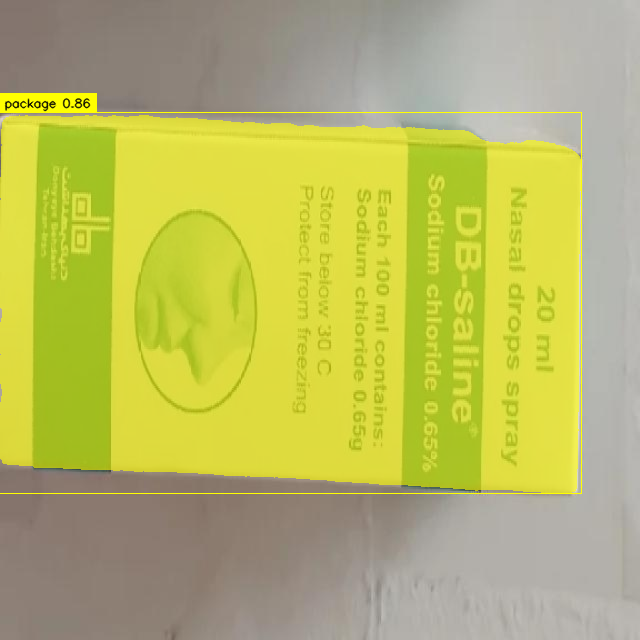

In [ ]:
from PIL import Image
from IPython.display import display

PROMPT = "package"
IMAGE_PATH = '/content/valid/images/20230812_210116_jpg.rf.13147b2b8c275b4409e5db95c58dd329.jpg'

image = Image.open(IMAGE_PATH).convert("RGB")
inference_state = processor.set_image(image)
inference_state = processor.set_text_prompt(state=inference_state, prompt=PROMPT)

detections = from_sam(sam_result=inference_state)
detections = detections[detections.confidence > 0.5]

print(f"There are {len(detections)} {PROMPT} objects detected in the image.\n")
annotate(image, detections, label=PROMPT)

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import shutil
import os

In [ ]:
data_root = Path("/content/the-drug-name-detection-dataset")
for image_path in tqdm(sorted(data_root.glob("*/images/*.jpg"))):
    if (image_path.parent.parent/ 'xyxy' / f"{image_path.stem}_xyxy.npy").exists():
        continue
    PROMPT = "package"

    image = Image.open(image_path).convert("RGB")
    inference_state = processor.set_image(image)
    inference_state = processor.set_text_prompt(state=inference_state, prompt=PROMPT)

    detections = from_sam(sam_result=inference_state)
    detections = detections[detections.confidence > 0.5]
    if len(detections.mask) == 0:
        # delete the image file
        os.remove(image_path)
        continue

    # save mask and xyxy
    mask = detections.mask[0]
    xyxy = detections.xyxy[0]

    mask_path  = image_path.parent.parent / 'masks' / f"{image_path.stem}_mask.npy"
    xyxy_path  = image_path.parent.parent / 'xyxy' / f"{image_path.stem}_xyxy.npy"

    np.save(mask_path, mask)
    np.save(xyxy_path, xyxy)


  0%|          | 0/1823 [00:00<?, ?it/s]

In [ ]:
! zip -q -r the-drug-name-detection-dataset.zip the-drug-name-detection-dataset
! cp the-drug-name-detection-dataset.zip "/content/drive/MyDrive/Colab Notebooks/Logo Detection/Dataset/the-drug-name-detection-dataset.zip"